# Stacking EMP candidates

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [3]:
emps = Table.read('../data/emp-candidates.fits', format='fits').to_pandas()
emps = emps.query('HA_N_FLUX / HB_N_FLUX < 10')

In [4]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

H = np.load('../data/contours.npy')  # This is for reference, comes from SDSS

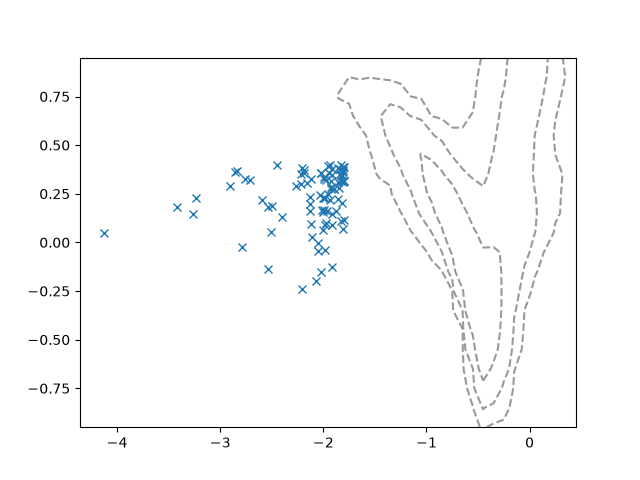

In [5]:
plt.figure(1, clear=True)

plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')
plt.plot(emps['N2'], emps['R3'], 'x')

plt.show()

In [6]:
R3_bins = [0.4, 0.25, 0.0]
N2_bins = [-1.8, -2, -2.25]

In [7]:
from pathlib import Path


def stack_spectra(targetids, emps, spectra_dir="../data/spectra", dwave=0.8, norm_window=(5950, 6050)):
    """
    Build an inverse-variance weighted stack of rest-frame spectra.

    Parameters
    ----------
    targetids : list of int
        TARGETIDs identifying the spectra to stack (files named f"{targetid}.fits"
        in `spectra_dir`, with 'wavelength', 'flux', 'ivar' columns).
    emps : pandas.DataFrame or astropy.table.Table
        Catalog used to look up the redshift (column 'Z') for each TARGETID.
    spectra_dir : str or Path, optional
        Directory containing the per-target spectrum fits files.
    dwave : float, optional
        Rest-frame wavelength step (in Angstroms) of the common output grid.
    norm_window : tuple of float, optional
        Rest-frame wavelength range (in Angstroms) used to normalize each
        spectrum by its mean flux before stacking (default: a line-free window
        around 6000 A).

    Returns
    -------
    stacked : astropy.table.Table
        Table with columns 'wavelength' (common rest-frame grid), 'flux'
        (inverse-variance weighted mean flux), 'ivar' (summed inverse
        variance of the flux estimate) and 'n_contrib' (number of spectra
        contributing, i.e. ivar > 0, at each grid point).
    """
    spectra_dir = Path(spectra_dir)
    emps_catalog = emps.to_pandas() if isinstance(emps, Table) else emps

    rest_waves, rest_fluxes, rest_ivars = [], [], []
    for targetid in targetids:
        matches = emps_catalog.loc[emps_catalog["TARGETID"] == targetid, "Z"]
        if matches.empty:
            raise ValueError(f"TARGETID {targetid} not found in emps.")
        z = float(matches.iloc[0])

        spec = Table.read(spectra_dir / f"{targetid}.fits", format="fits")
        wave = np.asarray(spec["wavelength"])
        flux = np.asarray(spec["flux"])
        ivar = np.asarray(spec["ivar"])

        # Shift to rest frame, conserving flux (and its variance) under the transform.
        rest_wave = wave / (1 + z)
        rest_flux = flux * (1 + z)
        rest_ivar = ivar / (1 + z) ** 2

        # Normalize by the mean continuum flux in a line-free window so all
        # spectra contribute on a comparable scale before weighting/stacking.
        norm_mask = (rest_wave >= norm_window[0]) & (rest_wave <= norm_window[1])
        norm = np.mean(rest_flux[norm_mask])
        if not np.isfinite(norm) or norm <= 0:
            raise ValueError(f"TARGETID {targetid}: invalid normalization flux ({norm}) in {norm_window}.")

        rest_waves.append(rest_wave)
        rest_fluxes.append(rest_flux / norm)
        rest_ivars.append(rest_ivar * norm ** 2)

    # Common rest-frame grid spanning the overlap of all input spectra.
    wave_min = max(w.min() for w in rest_waves)
    wave_max = min(w.max() for w in rest_waves)
    wave_grid = np.arange(wave_min, wave_max, dwave)

    ivar_sum = np.zeros_like(wave_grid)
    flux_ivar_sum = np.zeros_like(wave_grid)
    n_contrib = np.zeros_like(wave_grid, dtype=int)

    for wave, flux, ivar in zip(rest_waves, rest_fluxes, rest_ivars):
        order = np.argsort(wave)
        wave, flux, ivar = wave[order], flux[order], ivar[order]

        flux_i = np.interp(wave_grid, wave, flux)
        ivar_i = np.interp(wave_grid, wave, ivar, left=0.0, right=0.0)
        ivar_i[ivar_i < 0] = 0.0

        flux_ivar_sum += flux_i * ivar_i
        ivar_sum += ivar_i
        n_contrib += ivar_i > 0

    with np.errstate(invalid="ignore", divide="ignore"):
        stacked_flux = np.where(ivar_sum > 0, flux_ivar_sum / ivar_sum, np.nan)

    return Table(
        {
            "wavelength": wave_grid,
            "flux": stacked_flux,
            "ivar": ivar_sum,
            "n_contrib": n_contrib,
        }
    )


In [8]:
r3_edges = sorted(R3_bins)  # [0.0, 0.25, 0.4]
n2_edges = sorted(N2_bins)  # [-2.25, -2, -1.8]

excluded_targetids = [39627647168284280]

quadrants = {}
for i in range(len(r3_edges) - 1):
    r3_lo, r3_hi = r3_edges[i], r3_edges[i + 1]
    for j in range(len(n2_edges) - 1):
        n2_lo, n2_hi = n2_edges[j], n2_edges[j + 1]
        mask = (
            (emps['R3'] >= r3_lo) & (emps['R3'] < r3_hi)
            & (emps['N2'] >= n2_lo) & (emps['N2'] < n2_hi)
            & (~emps['TARGETID'].isin(excluded_targetids))
        )
        quadrants[(i, j)] = emps.loc[mask]
        print(f"R3 in [{r3_lo}, {r3_hi}), N2 in [{n2_lo}, {n2_hi}): {mask.sum()} objects")


R3 in [0.0, 0.25), N2 in [-2.25, -2): 10 objects
R3 in [0.0, 0.25), N2 in [-2, -1.8): 16 objects
R3 in [0.25, 0.4), N2 in [-2.25, -2): 9 objects
R3 in [0.25, 0.4), N2 in [-2, -1.8): 30 objects


In [9]:
stacks = {}
for key, subset in quadrants.items():
    targetids = subset['TARGETID']
    if len(targetids) == 0:
        continue
    stacks[key] = stack_spectra(
        targetids,
        emps,
        spectra_dir="../data/spectra",
        dwave=0.8,
        norm_window=(5950, 6050),
    )


In [10]:
stacks


{(0,
  0): <Table length=6726>
     wavelength             flux                ivar        n_contrib
      float64             float64             float64         int64  
 ------------------ -------------------- ------------------ ---------
 3571.0471940339844   1.0312320149424217 0.6046842324035224        10
 3571.8471940339846   1.7320326649835731 0.5902430918087925        10
 3572.6471940339848   1.8272670191199407 0.6198606588715867        10
  3573.447194033985   2.7708508426475493 0.6150820978916194        10
  3574.247194033985   2.8716251582852546 0.6463605082092061        10
 3575.0471940339853   1.5227740411329644 0.6594794245907135        10
 3575.8471940339855 -0.33947557643778625 0.6193092087367159        10
 3576.6471940339857   1.4830110770738014 0.5949987560632011        10
  3577.447194033986   2.1316320886454236  0.600113962579447        10
                ...                  ...                ...       ...
  8943.847194035206   0.5261842395821759 122.47663193904332

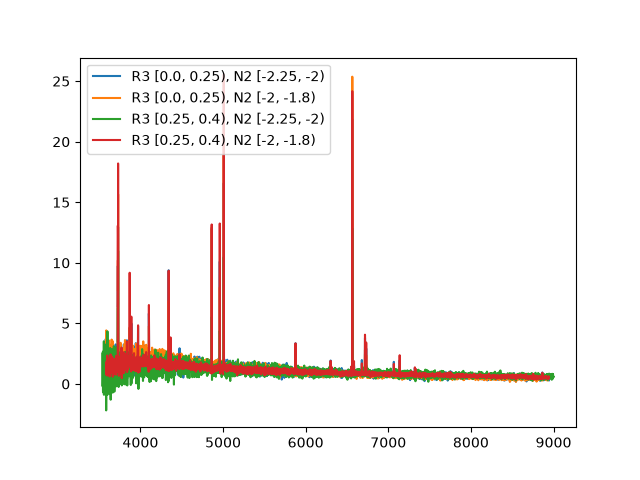

In [11]:
plt.figure(2, clear=True)

for (i, j), stacked in stacks.items():
    r3_lo, r3_hi = r3_edges[i], r3_edges[i + 1]
    n2_lo, n2_hi = n2_edges[j], n2_edges[j + 1]
    label = f"R3 [{r3_lo}, {r3_hi}), N2 [{n2_lo}, {n2_hi})"
    plt.plot(stacked["wavelength"], stacked["flux"], label=label)

plt.legend()
plt.show()


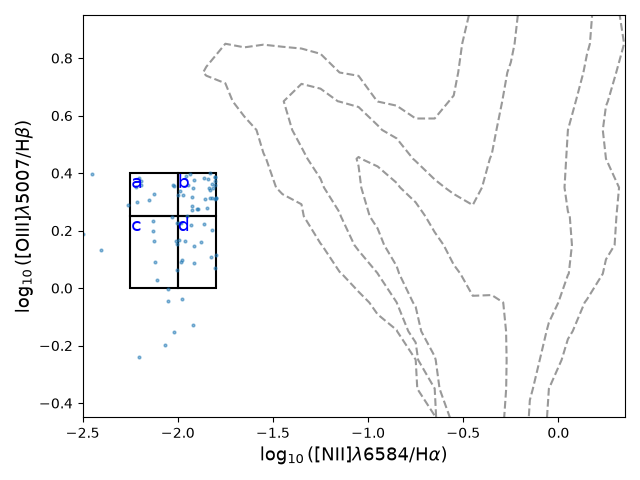

In [12]:
R3_bins = [0.4, 0.25, 0.0]
N2_bins = [-1.8, -2, -2.25]

r3_edges = sorted(R3_bins)
n2_edges = sorted(N2_bins)

plt.figure(3, clear=True)

plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')

for i in range(len(r3_edges) - 1):
    r3_lo, r3_hi = r3_edges[i], r3_edges[i + 1]
    for j in range(len(n2_edges) - 1):
        n2_lo, n2_hi = n2_edges[j], n2_edges[j + 1]
        rect = plt.Rectangle(
            (n2_lo, r3_lo),
            n2_hi - n2_lo,
            r3_hi - r3_lo,
            linewidth=1.5,
            edgecolor='k',
            facecolor='none',
        )
        plt.gca().add_patch(rect)


plt.plot(emps['N2'], emps['R3'], 'o', color='tab:blue', markersize=2, alpha=0.5)

plt.xlim(-2.5, 0.35)
plt.ylim(-0.45, 0.95)
plt.xlabel(r"$\log_{10}([\mathrm{NII}]\lambda6584 / \mathrm{H}\alpha)$", fontsize=13)
plt.ylabel(r"$\log_{10}([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$", fontsize=13)
plt.tight_layout()

plt.text(-2.245, 0.4, "a", va="top", ha="left", fontsize=14, color='b')
plt.text(-2., 0.4, "b", va="top", ha="left", fontsize=14, color='b')
plt.text(-2.245, 0.25, "c", va="top", ha="left", fontsize=14, color='b')
plt.text(-2., 0.25, "d", va="top", ha="left", fontsize=14, color='b')

plt.show()

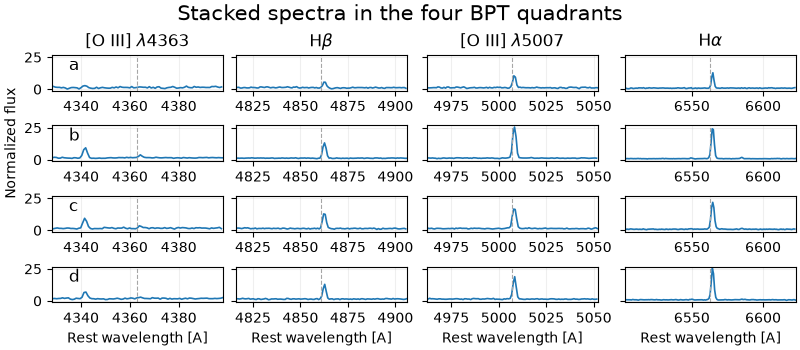

In [13]:
line_centers = [4363, 4861, 5007, 6563]
line_names = [r"[O III] $\lambda4363$", r"H$\beta$", r"[O III] $\lambda5007$", r"H$\alpha$"]
line_half_widths = [35, 45, 45, 60]

# Keep the BPT quadrants in the same top-to-bottom order as the diagram.
quadrant_order = [(1, 0), (1, 1), (0, 0), (0, 1)]
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(8, 3.5),
    sharey=True,
    constrained_layout=True,
    num=4,
    clear=True
)

for row, key in enumerate(quadrant_order):
    i, j = key
    r3_lo, r3_hi = r3_edges[i], r3_edges[i + 1]
    n2_lo, n2_hi = n2_edges[j], n2_edges[j + 1]
    row_label = f"R3 [{r3_lo}, {r3_hi})\nN2 [{n2_lo}, {n2_hi})"

    if key not in stacks:
        for axis in axes[row]:
            axis.text(0.5, 0.5, "no stack", ha="center", va="center", transform=axis.transAxes)
            axis.set_axis_off()
        continue

    stacked = stacks[key]
    wave_grid, stacked_flux = stacked["wavelength"], stacked["flux"]
    for col, (center, name, half_width) in enumerate(zip(line_centers, line_names, line_half_widths)):
        axis = axes[row, col]
        window = (wave_grid >= center - half_width) & (wave_grid <= center + half_width)
        axis.plot(wave_grid[window], stacked_flux[window], color="tab:blue", lw=1.2)
        axis.axvline(center, color="0.65", ls="--", lw=0.8)
        axis.set_xlim(center - half_width, center + half_width)
        axis.grid(alpha=0.2)
        if row == 0:
            axis.set_title(name)
        if row == len(quadrant_order) - 1:
            axis.set_xlabel("Rest wavelength [A]")

    # axes[row, 0].set_ylabel("Normalized flux")
    # axes[row, 0].annotate(
    #     row_label,
    #     xy=(0, 0.5),
    #     xytext=(-axes[row, 0].yaxis.labelpad - 34, 0),
    #     xycoords="axes fraction",
    #     textcoords="offset points",
    #     ha="right",
    #     va="center",
    #     fontsize=9,
    # )

axes[1, 0].set_ylabel("Normalized flux")
axes[0, 0].text(4335, 15, "a", fontsize=12)
axes[1, 0].text(4335, 15, "b", fontsize=12)
axes[2, 0].text(4335, 15, "c", fontsize=12)
axes[3, 0].text(4335, 15, "d", fontsize=12)

fig.suptitle("Stacked spectra in the four BPT quadrants", fontsize=15)
plt.show()


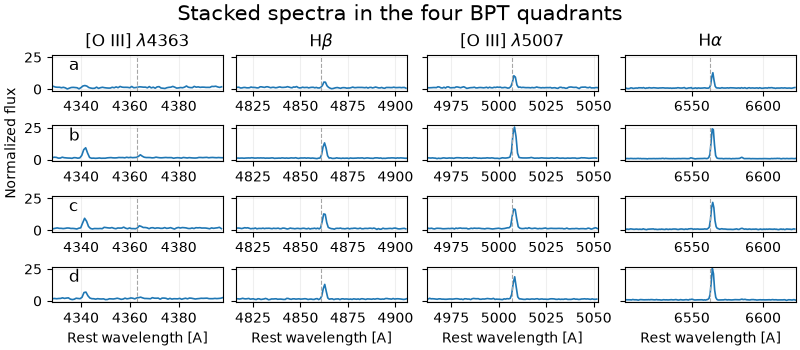

In [14]:
%run ../src/emline-inspect-functions.py

In [15]:
stack_a = fit_spectrum_lines(stacks[(1, 0)], z=0)
stack_b = fit_spectrum_lines(stacks[(1, 1)], z=0)
stack_c = fit_spectrum_lines(stacks[(0, 0)], z=0)
stack_d = fit_spectrum_lines(stacks[(0, 1)], z=0)

In [16]:
N2 = []
R3 = []

N2.append(np.log10(stack_a['ha_n2']['popt'][4] / stack_a['ha_n2']['popt'][3]))
N2.append(np.log10(stack_b['ha_n2']['popt'][4] / stack_b['ha_n2']['popt'][3]))
N2.append(np.log10(stack_c['ha_n2']['popt'][4] / stack_c['ha_n2']['popt'][3]))
N2.append(np.log10(stack_d['ha_n2']['popt'][4] / stack_d['ha_n2']['popt'][3]))

R3.append(np.log10(stack_a['hb']['popt'][2] / stack_a['o3_b']['popt'][2]))
R3.append(np.log10(stack_b['hb']['popt'][2] / stack_b['o3_b']['popt'][2]))
R3.append(np.log10(stack_c['hb']['popt'][2] / stack_c['o3_b']['popt'][2]))
R3.append(np.log10(stack_d['hb']['popt'][2] / stack_d['o3_b']['popt'][2]))

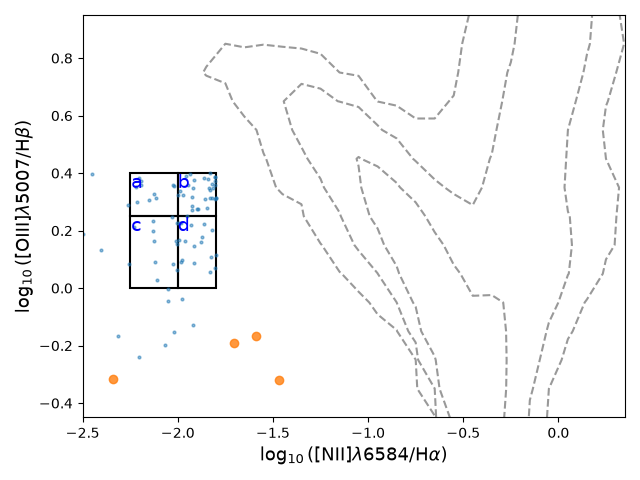

In [17]:
R3_bins = [0.4, 0.25, 0.0]
N2_bins = [-1.8, -2, -2.25]

r3_edges = sorted(R3_bins)
n2_edges = sorted(N2_bins)

plt.figure(5, clear=True)

plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')

for i in range(len(r3_edges) - 1):
    r3_lo, r3_hi = r3_edges[i], r3_edges[i + 1]
    for j in range(len(n2_edges) - 1):
        n2_lo, n2_hi = n2_edges[j], n2_edges[j + 1]
        rect = plt.Rectangle(
            (n2_lo, r3_lo),
            n2_hi - n2_lo,
            r3_hi - r3_lo,
            linewidth=1.5,
            edgecolor='k',
            facecolor='none',
        )
        plt.gca().add_patch(rect)


plt.plot(emps['N2'], emps['R3'], 'o', color='tab:blue', markersize=2, alpha=0.5)

plt.xlim(-2.5, 0.35)
plt.ylim(-0.45, 0.95)
plt.xlabel(r"$\log_{10}([\mathrm{NII}]\lambda6584 / \mathrm{H}\alpha)$", fontsize=13)
plt.ylabel(r"$\log_{10}([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$", fontsize=13)
plt.tight_layout()

plt.text(-2.245, 0.4, "a", va="top", ha="left", fontsize=14, color='b')
plt.text(-2., 0.4, "b", va="top", ha="left", fontsize=14, color='b')
plt.text(-2.245, 0.25, "c", va="top", ha="left", fontsize=14, color='b')
plt.text(-2., 0.25, "d", va="top", ha="left", fontsize=14, color='b')


plt.plot(N2, R3, 'o', color='tab:orange', markersize=6, alpha=0.8, label='Stacked spectra')

plt.show()